# **Trending YouTube Video Statistics**

## **1. Import Libraries and Dataset**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/monicagayatrik/default-of-credit-card-clients/default of credit card clients.xls


In [2]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pd.set_option('display.max_columns', None)

In [3]:
df_cc = pd.read_excel('/kaggle/input/datasets/monicagayatrik/default-of-credit-card-clients/default of credit card clients.xls')

## **2. Data Description**

In [4]:
df_cc.columns = df_cc.iloc[0]
df_cc = df_cc[1:]
df_cc.reset_index(drop=True, inplace=True)
df_cc.head(6)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,0


In [5]:
df_cc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          30000 non-null  object
 1   LIMIT_BAL                   30000 non-null  object
 2   SEX                         30000 non-null  object
 3   EDUCATION                   30000 non-null  object
 4   MARRIAGE                    30000 non-null  object
 5   AGE                         30000 non-null  object
 6   PAY_0                       30000 non-null  object
 7   PAY_2                       30000 non-null  object
 8   PAY_3                       30000 non-null  object
 9   PAY_4                       30000 non-null  object
 10  PAY_5                       30000 non-null  object
 11  PAY_6                       30000 non-null  object
 12  BILL_AMT1                   30000 non-null  object
 13  BILL_AMT2                   30000 non-null  ob

In [6]:
df_cc.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object', name=0)

**Detailed column explanation:**

This research employed a binary variable, default payment (Yes = 1, No = 0), as the response variable.

This study reviewed the literature and used the following 23 variables as explanatory variables:

* X1: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.
* X2: Gender (1 = male; 2 = female).
* X3: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).
* X4: Marital status (1 = married; 2 = single; 3 = others).
* X5: Age (year).
* X6 - X11: History of past payment. We tracked the past monthly payment records (from April to September, 2005) as follows: X6 = the repayment status in September, 2005; X7 = the repayment status in August, 2005; . . .;X11 = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.
* X12-X17: Amount of bill statement (NT dollar). X12 = amount of bill statement in September, 2005; X13 = amount of bill statement in August, 2005; . . .; X17 = amount of bill statement in April, 2005. 
* X18-X23: Amount of previous payment (NT dollar). X18 = amount paid in September, 2005; X19 = amount paid in August, 2005; . . .;X23 = amount paid in April, 2005.

## **3. Numeric Statistic**

In [7]:
df_cc.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000
unique,30000,81,2,7,4,56,11,11,11,11,10,10,22723,22346,22026,21548,21010,20604,7943,7899,7518,6937,6897,6939,2
top,29984,50000,2,2,2,29,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
freq,1,3365,18112,14030,15964,1605,14737,15730,15764,16455,16947,16286,2008,2506,2870,3195,3506,4020,5249,5396,5968,6408,6703,7173,23364


## **4. Data Featuring Engineering**

### **4.1 Missing Data**

In [8]:
len(df_cc.isna())/len(df_cc)

1.0

### **4.2 Duplicate Value**

In [9]:
len(df_cc.duplicated())

30000

### **4.3 Outlier Data**

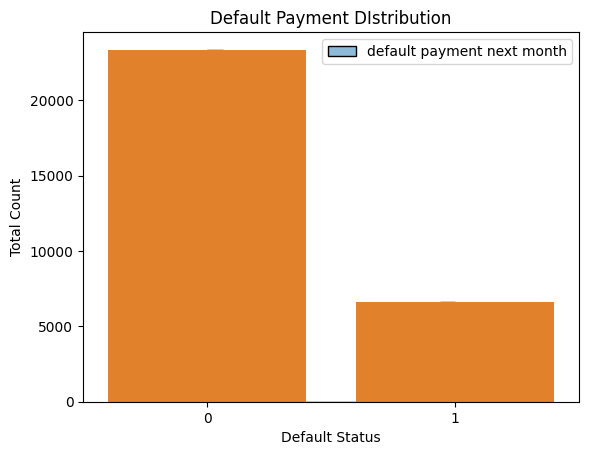

In [10]:
sns.histplot(df_cc[['default payment next month']])

tgt_count = df_cc['default payment next month'].value_counts()
sns.barplot(x=tgt_count.index, y=tgt_count.values)
plt.title('Default Payment DIstribution')
plt.xlabel('Default Status')
plt.ylabel('Total Count')

plt.show()

The appliance showing a huge different total count, between default payment No=0 and Yes=1.

as the dataset don't have any NaN and duplicated values, let's use **StratifiedShuffleSplit** to equally distributed the dataset to training dataset and test dataset.

## **5. Splitting Data Set**

In [11]:
df_cc = df_cc.astype(int)

In [12]:
df_cc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [13]:
from sklearn.model_selection import StratifiedShuffleSplit

X = df_cc.drop(columns=['default payment next month'])
y = df_cc['default payment next month']
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

In [14]:
for train_index, test_index in sss.split(X, y):
    
    # Extract the training matrices using the generated train_index array
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    
    # Extract the testing matrices using the generated test_index array
    X_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

# Output verification
print(f"Training Matrix Dimensionality: {X_train.shape} and {y_train.shape}")
print(f"Testing Matrix Dimensionality: {X_test.shape} and {y_test.shape}")

Training Matrix Dimensionality: (24000, 24) and (24000,)
Testing Matrix Dimensionality: (6000, 24) and (6000,)


## **6. Training The Models**

In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


X_train = X_train.astype(float)
X_test = X_test.astype(float)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}


estimators = [
    ('lr', base_models['Logistic Regression']),
    ('knn', base_models['KNN']),
    ('svm', base_models['SVM']),
    ('rf', base_models['Random Forest']),
    ('gb', base_models['Gradient Boosting'])
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)


all_models = base_models.copy()
all_models['Stacking Ensemble'] = stacking_clf

results = []


for name, model in all_models.items():
    
    model.fit(X_train_scaled, y_train)
    
    
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] 
    
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)


print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0    Gradient Boosting  0.819333   0.668516  0.363225  0.470703  0.778998
1    Stacking Ensemble  0.819167   0.659631  0.376790  0.479616  0.776915
2        Random Forest  0.814667   0.642762  0.364732  0.465385  0.756570
3                  SVM  0.816667   0.669656  0.337604  0.448898  0.724140
4  Logistic Regression  0.808000   0.688172  0.241145  0.357143  0.707777
5                  KNN  0.793500   0.553012  0.345893  0.425591  0.694213


## **7. Cross-Validation and Regularization**

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


base_models = {
    'Logistic Regression (L2 Regularized)': LogisticRegression(penalty='l2', C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

estimators = [
    ('lr', base_models['Logistic Regression (L2 Regularized)']),
    ('knn', base_models['KNN']),
    ('svm', base_models['SVM']),
    ('rf', base_models['Random Forest']),
    ('gb', base_models['Gradient Boosting'])
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight='balanced'),
    cv=5
)

all_models = base_models.copy()
all_models['Stacking Ensemble'] = stacking_clf

# Define the Cross-Validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = {'roc_auc': 'roc_auc', 'recall': make_scorer(recall_score)}

cv_results = []

print("Executing Phase 2: Stratified Cross-Validation...")
for name, model in all_models.items():
    # cross_validate computes metrics across 5 isolated data folds to calculate variance
    cv_scores = cross_validate(model, X_train_scaled, y_train, cv=cv_strategy, scoring=scoring_metrics, n_jobs=-1)
    
    cv_results.append({
        'Model': name,
        'Mean CV ROC-AUC': np.mean(cv_scores['test_roc_auc']),
        'Mean CV Recall': np.mean(cv_scores['test_recall'])
    })

cv_df = pd.DataFrame(cv_results).sort_values(by='Mean CV ROC-AUC', ascending=False).reset_index(drop=True)
print("\n--- Cross-Validation Baseline Results ---")
print(cv_df)

Executing Phase 2: Stratified Cross-Validation...

--- Cross-Validation Baseline Results ---
                                  Model  Mean CV ROC-AUC  Mean CV Recall
0                     Stacking Ensemble         0.783068        0.586553
1                     Gradient Boosting         0.781002        0.369750
2                         Random Forest         0.769144        0.340363
3                                   SVM         0.760427        0.588060
4  Logistic Regression (L2 Regularized)         0.726495        0.645701
5                                   KNN         0.697787        0.345452


## **8. Hyperparameter Tuning**

In [17]:
print("\nExecuting Phase 3: Hyperparameter Tuning (GridSearchCV)...")

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0], # Inverse of regularization strength
    'penalty': ['l1', 'l2'],            # L1 for feature selection, L2 for coefficient shrinkage
    'solver': ['liblinear']             # Required solver for L1 penalty compatibility
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid=param_grid_lr,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
best_tuned_model = grid_search.best_estimator_

print("\n--- Optimal Hyperparameters Found ---")
print(grid_search.best_params_)


Executing Phase 3: Hyperparameter Tuning (GridSearchCV)...

--- Optimal Hyperparameters Found ---
{'C': 10.0, 'penalty': 'l1', 'solver': 'liblinear'}


## **9. Final Evaluation**

In [18]:
print("\nExecuting Phase 4: Final Test Matrix Evaluation...")

y_pred_final = best_tuned_model.predict(X_test_scaled)
y_prob_final = best_tuned_model.predict_proba(X_test_scaled)[:, 1]

final_results = pd.DataFrame([{
    'Model': 'Tuned Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_final),
    'Precision': precision_score(y_test, y_pred_final, zero_division=0),
    'Recall': recall_score(y_test, y_pred_final, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_final, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_prob_final)
}])

print("\n--- Final Out-of-Sample Performance ---")
print(final_results)


Executing Phase 4: Final Test Matrix Evaluation...

--- Final Out-of-Sample Performance ---
                       Model  Accuracy  Precision   Recall  F1-Score   ROC-AUC
0  Tuned Logistic Regression  0.681333    0.36901  0.62095  0.462921  0.708445
